# Практикум по логистической регрессии: группы 2 и 4

## Подготовка к работе

In [1]:
import numpy as np
import pandas as pd
import statsmodels.formula.api as smf

from matplotlib import pyplot as plt
from sklearn.metrics import roc_curve, roc_auc_score

/opt/anaconda3/lib/python3.7/site-packages/statsmodels/tools/_testing.py:19: FutureWarning: pandas.util.testing is deprecated. Use the functions in the public API at pandas.testing instead.
  import pandas.util.testing as tm


In [2]:
job = pd.read_csv("https://raw.githubusercontent.com/allatambov/PyPerm25/refs/heads/main/HR.csv")
job.head()

,satisfaction_level,number_project,average_montly_hours,time_spend_company,left,promotion_last_5years,Department,salary
0,0.38,2,157,3,1,0,sales,low
1,0.80,5,262,6,1,0,sales,medium
2,0.11,7,272,4,1,0,sales,medium
3,0.72,5,223,5,1,0,sales,low
4,0.37,2,159,3,1,0,sales,low


In [3]:
job["Department"].value_counts()

sales          4140
technical      2720
support        2229
IT             1227
product_mng     902
marketing       858
RandD           787
accounting      767
hr              739
management      630
Name: Department, dtype: int64

In [9]:
df = job[job["Department"] == "IT"]
df.describe()

,satisfaction_level,number_project,average_montly_hours,time_spend_company,left,promotion_last_5years
count,1227.000000,1227.000000,1227.000000,1227.000000,1227.000000,1227.000000
mean,0.618142,3.816626,202.215974,3.468623,0.222494,0.002445
std,0.249903,1.221658,50.688311,1.408302,0.416091,0.049406
min,0.090000,2.000000,96.000000,2.000000,0.000000,0.000000
25%,0.450000,3.000000,160.000000,3.000000,0.000000,0.000000
50%,0.660000,4.000000,199.000000,3.000000,0.000000,0.000000
75%,0.820000,5.000000,245.000000,4.000000,0.000000,0.000000
max,1.000000,7.000000,308.000000,10.000000,1.000000,1.000000


In [10]:
df["salary"].value_counts()

low       609
medium    535
high       83
Name: salary, dtype: int64

## Часть 1: строим модель с `statsmodels` (статистический подход)

### Оценка модели и интерпретация коэффициентов

In [11]:
equation = """
left ~ satisfaction_level + 
number_project + salary + time_spend_company
"""

In [12]:
logit01 = smf.logit(equation, data = df).fit()
print(logit01.summary())

Optimization terminated successfully.
         Current function value: 0.413859
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:                   left   No. Observations:                 1227
Model:                          Logit   Df Residuals:                     1221
Method:                           MLE   Df Model:                            5
Date:                Sat, 07 Jun 2025   Pseudo R-squ.:                  0.2192
Time:                        03:45:08   Log-Likelihood:                -507.80
converged:                       True   LL-Null:                       -650.37
Covariance Type:            nonrobust   LLR p-value:                 1.578e-59
                         coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
Intercept             -0.9484      0.637     -1.489      0.137      -2.197       0.300
salar

In [13]:
print(logit01.params)

Intercept            -0.948395
salary[T.low]         2.133535
salary[T.medium]      1.469930
satisfaction_level   -4.482586
number_project       -0.075472
time_spend_company    0.189230
dtype: float64


In [14]:
names = logit01.params.index
coefs = logit01.params.values.round(2)
print(*zip(names, coefs), sep = "\n")

('Intercept', -0.95)
('salary[T.low]', 2.13)
('salary[T.medium]', 1.47)
('satisfaction_level', -4.48)
('number_project', -0.08)
('time_spend_company', 0.19)


In [15]:
print(np.exp(coefs))

[0.38674102 8.41486681 4.34923514 0.01133341 0.92311635 1.2092496 ]


In [16]:
print(*zip(names, np.exp(coefs).round(2)), sep = "\n")

('Intercept', 0.39)
('salary[T.low]', 8.41)
('salary[T.medium]', 4.35)
('satisfaction_level', 0.01)
('number_project', 0.92)
('time_spend_company', 1.21)


In [17]:
marg_effect_mean = logit01.get_margeff(at = "mean", method = "dydx")
print(marg_effect_mean.summary())

        Logit Marginal Effects       
Dep. Variable:                   left
Method:                          dydx
At:                              mean
                        dy/dx    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
salary[T.low]          0.2881      0.070      4.088      0.000       0.150       0.426
salary[T.medium]       0.1985      0.072      2.751      0.006       0.057       0.340
satisfaction_level    -0.6054      0.045    -13.414      0.000      -0.694      -0.517
number_project        -0.0102      0.008     -1.268      0.205      -0.026       0.006
time_spend_company     0.0256      0.007      3.455      0.001       0.011       0.040


In [20]:
marg_effect_median = logit01.get_margeff(at = "median", method = "dydx")
print(marg_effect_median.summary())

        Logit Marginal Effects       
Dep. Variable:                   left
Method:                          dydx
At:                            median
                        dy/dx    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
salary[T.low]          0.0531      0.014      3.696      0.000       0.025       0.081
salary[T.medium]       0.0366      0.007      5.438      0.000       0.023       0.050
satisfaction_level    -0.1116      0.057     -1.968      0.049      -0.223      -0.000
number_project        -0.0019      0.002     -1.076      0.282      -0.005       0.002
time_spend_company     0.0047      0.003      1.734      0.083      -0.001       0.010


In [21]:
ave_marg_effect = logit01.get_margeff(at = "overall", method = "dydx")
print(ave_marg_effect.summary())

        Logit Marginal Effects       
Dep. Variable:                   left
Method:                          dydx
At:                           overall
                        dy/dx    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------
salary[T.low]          0.2794      0.070      3.967      0.000       0.141       0.417
salary[T.medium]       0.1925      0.072      2.688      0.007       0.052       0.333
satisfaction_level    -0.5870      0.033    -17.771      0.000      -0.652      -0.522
number_project        -0.0099      0.008     -1.256      0.209      -0.025       0.006
time_spend_company     0.0248      0.007      3.484      0.000       0.011       0.039


### Оценка качества модели: ROC-кривая и AUC

In [22]:
df["prob"] =  logit01.predict()
df.head()

/opt/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  """Entry point for launching an IPython kernel.


,satisfaction_level,number_project,average_montly_hours,time_spend_company,left,promotion_last_5years,Department,salary,prob
61,0.11,7,308,4,1,0,IT,medium,0.563914
62,0.10,6,244,5,1,0,IT,medium,0.637976
63,0.36,2,132,3,1,0,IT,medium,0.337277
64,0.11,6,286,4,1,0,IT,medium,0.582376
65,0.81,6,161,4,1,0,IT,medium,0.057040


In [23]:
fpr, tpr, thresholds = roc_curve(df["left"], df["prob"])

print("Cutoff points: ", thresholds[::50])
print("FPR: ", fpr[::50])
print("TPR: ", tpr[::50])

Cutoff points:  [1.80458052 0.49703845 0.28092501 0.18653748 0.13550479 0.10063333
 0.0725281  0.05616294 0.02329775]
FPR:  [0.         0.0639413  0.16981132 0.30293501 0.42348008 0.53459119
 0.66771488 0.78616352 0.95073375]
TPR:  [0.         0.36630037 0.67765568 0.73626374 0.80586081 0.8974359
 0.94139194 0.98168498 0.996337  ]


In [24]:
logit_roc_auc = roc_auc_score(df["left"], df["prob"])
print("AUC:", round(logit_roc_auc, 2))

AUC: 0.81


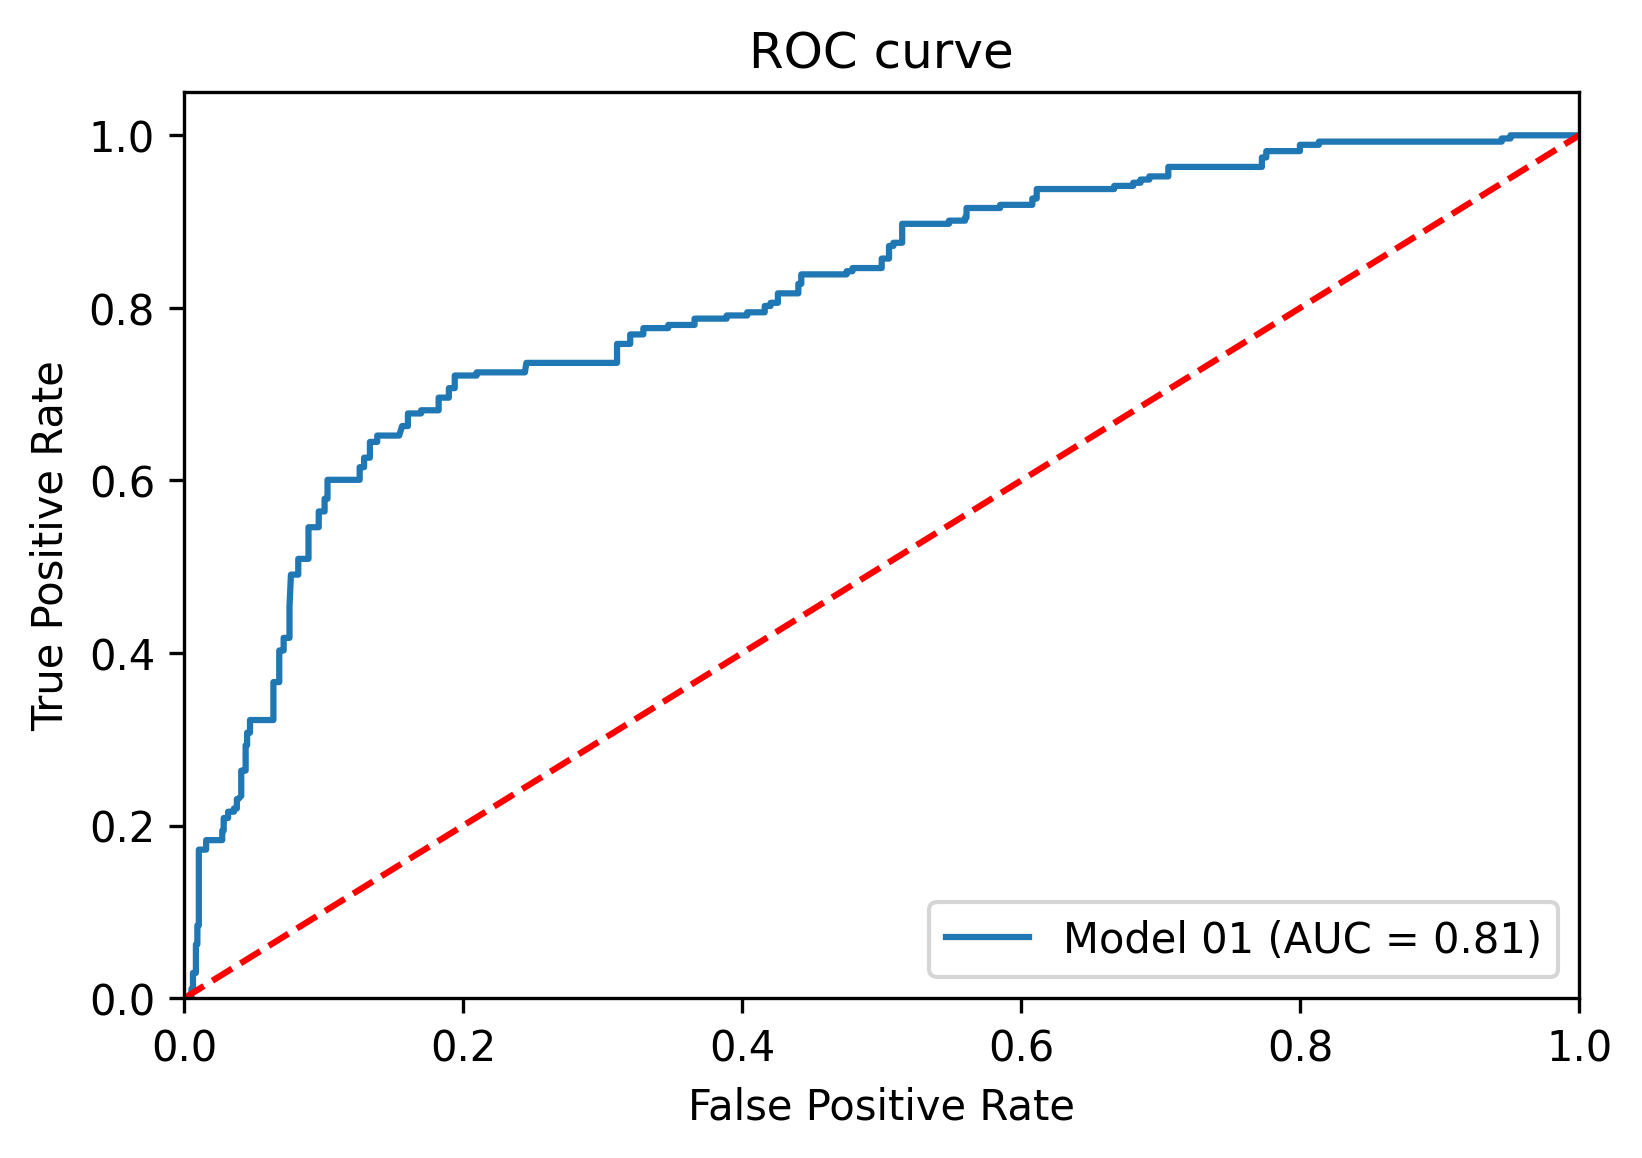

In [25]:
plt.figure(dpi = 300)
plt.plot(fpr, tpr, label = f'Model 01 (AUC = {logit_roc_auc:.2f})' )
plt.plot([0, 1], [0, 1],'r--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC curve')
plt.legend(loc = "lower right")
plt.show()

### Предсказание вероятностей

In [26]:
logit01.predict(exog = {"salary" : "low", 
                       "satisfaction_level" : 0.2, 
                       "number_project" : 3, 
                        "time_spend_company" : 2})

0    0.608418
dtype: float64

In [27]:
logit01.predict(exog = {"salary" : ["low", "high", "medium"], 
                       "satisfaction_level" : [0.2, 0.8, 0.5],
                       "number_project" : [3, 1, 5], 
                       "time_spend_company" : [2, 5, 1]})

0    0.608418
1    0.024994
2    0.129218
dtype: float64

### Классификация с помощью модели

In [28]:
tab = logit01.pred_table()
print(tab)

[[893.  61.]
 [185.  88.]]


In [29]:
TN = tab[0, 0]
TP = tab[1, 1]
FN = tab[1, 0]
FP = tab[0, 1]

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

print("Sensitivity:", round(sensitivity, 2)) 
print("Specificity:", round(specificity, 2))

Sensitivity: 0.32
Specificity: 0.94


In [30]:
df["left"].value_counts(normalize = True)

0    0.777506
1    0.222494
Name: left, dtype: float64

In [31]:
tab2 = logit01.pred_table(threshold = 0.222)

TN2 = tab2[0, 0]
TP2 = tab2[1, 1]
FN2 = tab2[1, 0]
FP2 = tab2[0, 1]

sensitivity2 = TP2 / (TP2 + FN2)
specificity2 = TN2 / (TN2 + FP2)

print("Sensitivity:", round(sensitivity2, 2)) 
print("Specificity:", round(specificity2, 2))

Sensitivity: 0.73
Specificity: 0.76


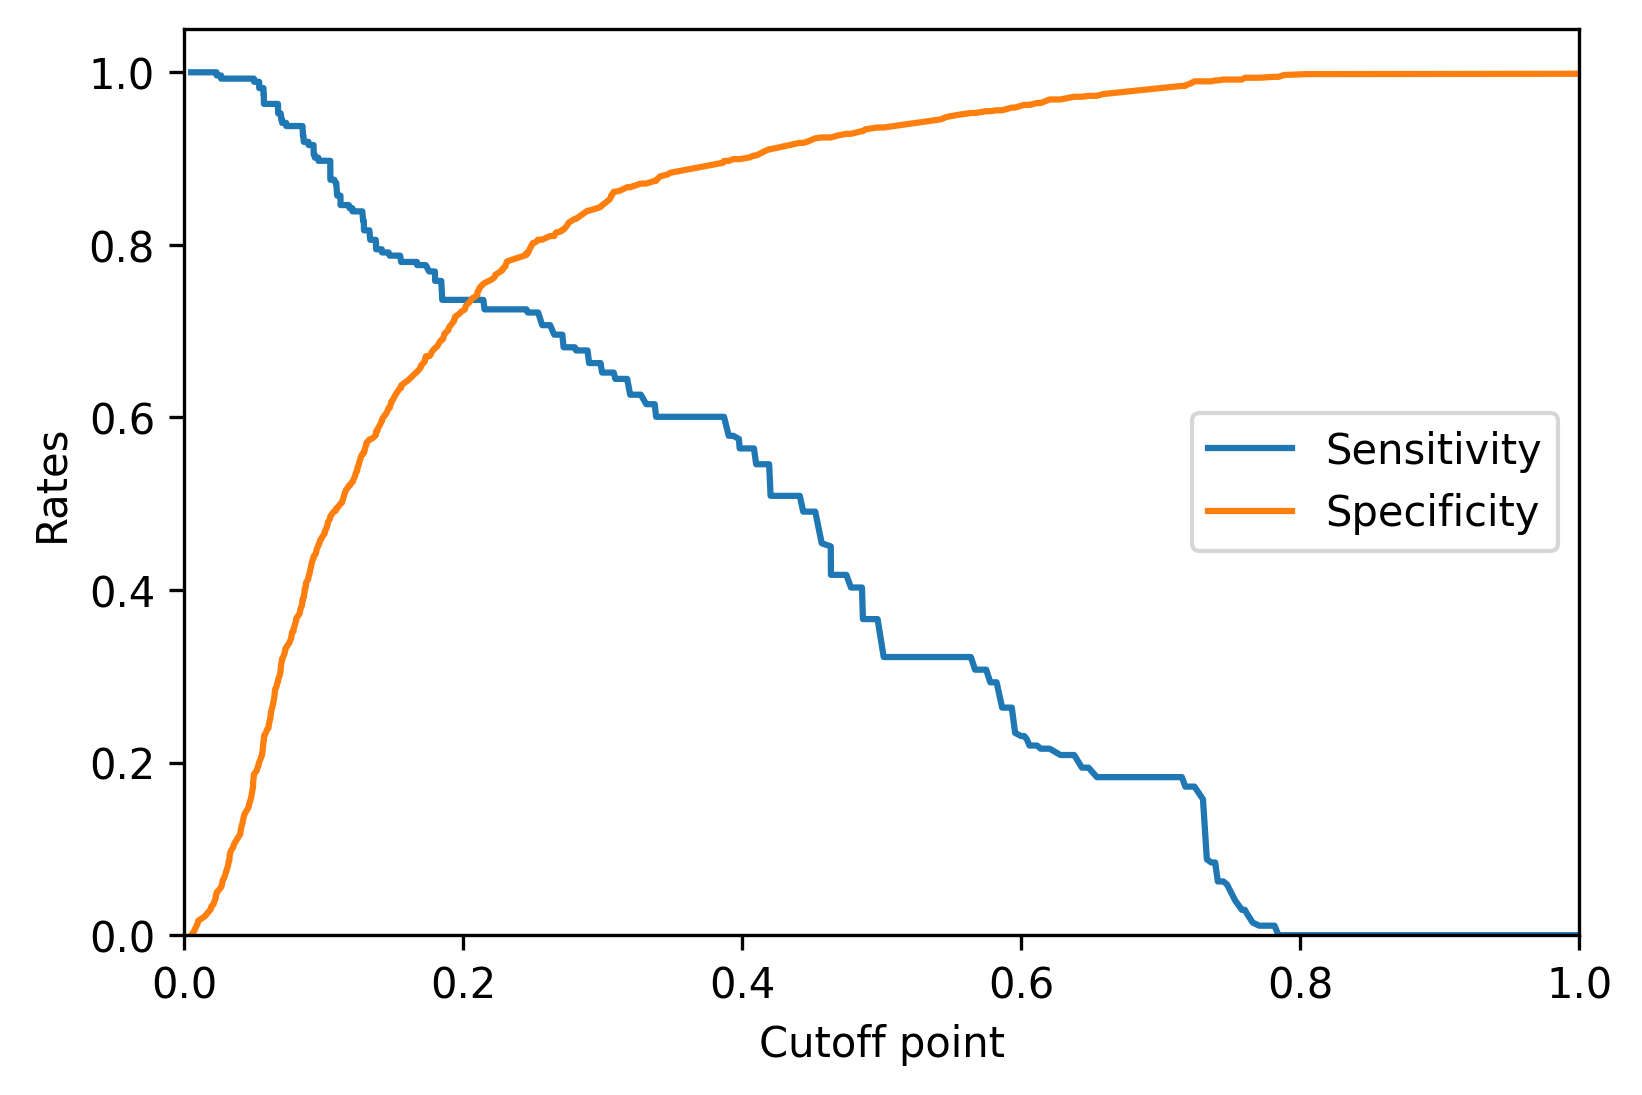

In [32]:
plt.figure(dpi = 300)
plt.plot(thresholds, tpr, label = "Sensitivity")
plt.plot(thresholds, 1 - fpr, label = "Specificity")
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Cutoff point')
plt.ylabel('Rates')
plt.legend()
plt.show()

## Часть 2: строим модель с `sklearn` (машинное обучение)

In [33]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

In [34]:
salary = pd.get_dummies(df["salary"])
print(salary.head())

    high  low  medium
61     0    0       1
62     0    0       1
63     0    0       1
64     0    0       1
65     0    0       1


In [35]:
fin = pd.concat([df, salary], axis = 1)
fin.head()

,satisfaction_level,number_project,average_montly_hours,time_spend_company,left,promotion_last_5years,Department,salary,prob,high,low,medium
61,0.11,7,308,4,1,0,IT,medium,0.563914,0,0,1
62,0.10,6,244,5,1,0,IT,medium,0.637976,0,0,1
63,0.36,2,132,3,1,0,IT,medium,0.337277,0,0,1
64,0.11,6,286,4,1,0,IT,medium,0.582376,0,0,1
65,0.81,6,161,4,1,0,IT,medium,0.057040,0,0,1


In [36]:
y = fin["left"]
X = fin[["satisfaction_level", "number_project", 
         "low", "medium", "time_spend_company"]]

In [68]:
X_train, X_test, y_train, y_test = train_test_split(X, y, 
                                                    test_size=0.15, 
                                                    random_state=480)

In [69]:
clf = LogisticRegression()
clf.fit(X_train, y_train)

LogisticRegression()

In [70]:
print("Intercept:", clf.intercept_)
print("Coeffs:", clf.coef_)

Intercept: [-0.65645358]
Coeffs: [[-4.10374978 -0.03483423  1.52725252  0.81300724  0.1905284 ]]


In [71]:
accuracy = accuracy_score(y_test, clf.predict(X_test))
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.76


In [72]:
clf.predict(X_test)

array([0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1, 1, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
       1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0,
       1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0,
       0, 0, 1, 0, 0, 0, 0, 0, 0])

In [73]:
clf.predict_proba(X_test)

array([[0.93862956, 0.06137044],
       [0.98632561, 0.01367439],
       [0.94033062, 0.05966938],
       [0.42573182, 0.57426818],
       [0.7958934 , 0.2041066 ],
       [0.71950186, 0.28049814],
       [0.80071491, 0.19928509],
       [0.60859021, 0.39140979],
       [0.58127143, 0.41872857],
       [0.46279172, 0.53720828],
       [0.94739623, 0.05260377],
       [0.94739623, 0.05260377],
       [0.93178105, 0.06821895],
       [0.56679442, 0.43320558],
       [0.73576405, 0.26423595],
       [0.90804764, 0.09195236],
       [0.84191085, 0.15808915],
       [0.92401227, 0.07598773],
       [0.90257576, 0.09742424],
       [0.93124159, 0.06875841],
       [0.95385404, 0.04614596],
       [0.86924621, 0.13075379],
       [0.34379059, 0.65620941],
       [0.96633335, 0.03366665],
       [0.87491338, 0.12508662],
       [0.62598002, 0.37401998],
       [0.92218435, 0.07781565],
       [0.76172179, 0.23827821],
       [0.92232408, 0.07767592],
       [0.91979147, 0.08020853],
       [0.

In [74]:
clf.predict_proba(X_test)[:, 1]

array([0.06137044, 0.01367439, 0.05966938, 0.57426818, 0.2041066 ,
       0.28049814, 0.19928509, 0.39140979, 0.41872857, 0.53720828,
       0.05260377, 0.05260377, 0.06821895, 0.43320558, 0.26423595,
       0.09195236, 0.15808915, 0.07598773, 0.09742424, 0.06875841,
       0.04614596, 0.13075379, 0.65620941, 0.03366665, 0.12508662,
       0.37401998, 0.07781565, 0.23827821, 0.07767592, 0.08020853,
       0.02414414, 0.62334891, 0.72561646, 0.07362459, 0.19337326,
       0.69651822, 0.19281744, 0.18210333, 0.06294969, 0.08504701,
       0.23768639, 0.11614579, 0.12576709, 0.07158259, 0.22066138,
       0.07781565, 0.40326078, 0.10801135, 0.59803457, 0.44330814,
       0.16372213, 0.18181326, 0.62594951, 0.35195554, 0.15245154,
       0.58276177, 0.09959363, 0.05375227, 0.18036433, 0.67569082,
       0.03281895, 0.10015129, 0.23827821, 0.10521898, 0.26082868,
       0.2020496 , 0.19139842, 0.33951911, 0.41317407, 0.07335559,
       0.09044179, 0.08484212, 0.04317456, 0.06997592, 0.18834

In [75]:
auc = roc_auc_score(y_test, clf.predict_proba(X_test)[:, 1])
print("AUC:", round(auc, 2))

AUC: 0.78


In [76]:
clf.predict_proba(X_test)[:, 1] >= 0.5

array([False, False, False,  True, False, False, False, False, False,
        True, False, False, False, False, False, False, False, False,
       False, False, False, False,  True, False, False, False, False,
       False, False, False, False,  True,  True, False, False,  True,
       False, False, False, False, False, False, False, False, False,
       False, False, False,  True, False, False, False,  True, False,
       False,  True, False, False, False,  True, False, False, False,
       False, False, False, False, False, False, False, False, False,
       False, False, False,  True, False,  True, False,  True, False,
        True,  True,  True, False, False, False, False, False, False,
       False, False,  True,  True, False, False,  True, False, False,
       False,  True, False, False, False, False, False, False,  True,
       False, False, False, False, False, False,  True, False, False,
       False,  True, False, False, False, False, False, False, False,
       False, False,

### Задание

Вычислите значение *accuracy* для модели, изменив пороговое значение вероятности на долю 1 в тестовой выборке, округленную до сотых.